<a href="https://colab.research.google.com/github/Sparda07/CNN-Classification-/blob/main/CNN_22_49860_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


Importing the Dataset

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")

print("Path to dataset files:", path)
print("Contents:", os.listdir(path))  # Shows class folders directly

Using Colab cache for faster access to the 'fruits-fresh-and-rotten-for-classification' dataset.
Path to dataset files: /kaggle/input/fruits-fresh-and-rotten-for-classification
Contents: ['dataset']


In [ ]:
import torchvision.transforms as transforms
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),        # resize to model input size
    transforms.RandomHorizontalFlip(),    # horizontal flip augmentation
    transforms.RandomRotation(15),        # rotate ±15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),                # convert PIL → tensor [0,1]

    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),

    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

import os
path = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")

# Correct paths - dataset/ is the extra layer
train_folder = os.path.join(path, "dataset", "train")
test_folder = os.path.join(path, "dataset", "test")

train_data = datasets.ImageFolder(train_folder, transform=train_transform)
test_data = datasets.ImageFolder(test_folder, transform=val_transform)
print(f"Train: {len(train_data)}")
print(f"Test: {len(test_data)}")

Using Colab cache for faster access to the 'fruits-fresh-and-rotten-for-classification' dataset.
Train: 10901
Test: 2698


Let Us see a data using plt

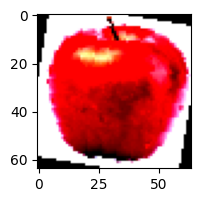

In [ ]:
plt.figure(figsize = (2,2))
plt.imshow(train_data[100][0].permute(1,2,0))

Let us set parameters and Batch size

In [ ]:
batch_size = 32
learning_rate=0.001
minimum_learning_rate=1e-4
epochs = 20

Training Data Loading

In [ ]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,num_workers=2)
val_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True, num_workers=2)

Model Arc

In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

class CNNModel(nn.Module):
    def __init__(self, num_classes=6):
        super(CNNModel, self).__init__()

        # Convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3),  # 3x64x64 -> 64x62x62
            nn.MaxPool2d(2),                  # 64x31x31
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3),# 128x29x29
            nn.MaxPool2d(2),                  # 128x14x14
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3),# 128x12x12
            nn.MaxPool2d(2),                   # 128x6x6
            nn.ReLU()
        )

        # Fully connected layers/Classification Head/ANN
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*6*6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

#1. Get the Model
model = CNNModel(num_classes=len(train_data.classes)).to(device)
# 2. Define optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)
# 3. Define LR scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=minimum_learning_rate)
# 4. Define loss function
criterion = nn.CrossEntropyLoss()

from torchsummary import summary
summary(model, input_size=(3,64,64));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 62, 62]           1,792
         MaxPool2d-2           [-1, 64, 31, 31]               0
              ReLU-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 128, 29, 29]          73,856
         MaxPool2d-5          [-1, 128, 14, 14]               0
              ReLU-6          [-1, 128, 14, 14]               0
            Conv2d-7          [-1, 128, 12, 12]         147,584
         MaxPool2d-8            [-1, 128, 6, 6]               0
              ReLU-9            [-1, 128, 6, 6]               0
          Flatten-10                 [-1, 4608]               0
           Linear-11                  [-1, 256]       1,179,904
             ReLU-12                  [-1, 256]               0
          Dropout-13                  [-1, 256]               0
           Linear-14                   

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # compute accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(loader)
    train_acc = correct / total

    return train_loss, train_acc

def validate_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

In [ ]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    print(f"----------------------------------------------------")
    print(f"Epoch {epoch+1}/{epochs}, LR: {optimizer.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

----------------------------------------------------
Epoch 1/20, LR: 0.001
Train Loss: 0.6621 | Train Acc: 0.7609
Val Loss: 0.2966 | Val Acc: 0.9021
----------------------------------------------------
Epoch 2/20, LR: 0.00099446
Train Loss: 0.3384 | Train Acc: 0.8823
Val Loss: 0.2293 | Val Acc: 0.9148
----------------------------------------------------
Epoch 3/20, LR: 0.000977975
Train Loss: 0.2611 | Train Acc: 0.9114
Val Loss: 0.1719 | Val Acc: 0.9329
----------------------------------------------------
Epoch 4/20, LR: 0.000950953
Train Loss: 0.2205 | Train Acc: 0.9208
Val Loss: 0.1268 | Val Acc: 0.9555
----------------------------------------------------
Epoch 5/20, LR: 0.000914058
Train Loss: 0.1883 | Train Acc: 0.9347
Val Loss: 0.1066 | Val Acc: 0.9603
----------------------------------------------------
Epoch 6/20, LR: 0.000868198
Train Loss: 0.1617 | Train Acc: 0.9425
Val Loss: 0.0691 | Val Acc: 0.9744
----------------------------------------------------
Epoch 7/20, LR: 0.000814

Image path: /kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/test/rottenbanana/rotated_by_30_Screen Shot 2018-06-12 at 8.49.20 PM.png


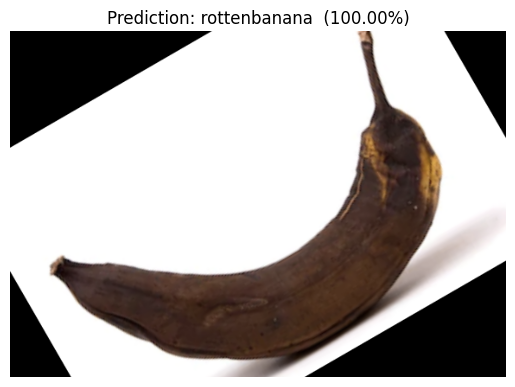

Predicted Class : rottenbanana
Confidence      : 100.00%


In [ ]:
from PIL import Image

# ✅ Pick any image directly from the test folder
sample_image_path = test_data.samples[1890][0]  # [0] = path, [1] = label
print("Image path:", sample_image_path)

def predict(image_path, model, transform, classes, device):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    label = classes[predicted.item()]
    conf  = confidence.item() * 100

    plt.imshow(Image.open(image_path))
    plt.title(f"Prediction: {label}  ({conf:.2f}%)")
    plt.axis("off")
    plt.show()

    print(f"Predicted Class : {label}")
    print(f"Confidence      : {conf:.2f}%")

predict(
    image_path = sample_image_path,
    model      = model,
    transform  = val_transform,
    classes    = train_data.classes,
    device     = device
)